# Decision Tree — Strategy A: SMOTE Oversampling

A Decision Tree classifier is trained using SMOTE oversampling to address class imbalance between diabetic and non-diabetic participants. SMOTE generates synthetic samples for the minority class inside each training fold, preventing data leakage into the validation fold.

This notebook is the direct counterpart of `decision_tree_B.ipynb` (random undersampling), allowing a controlled comparison of how the preprocessing strategy affects predictive performance and feature importance rankings (RQ3).

Hyperparameter tuning is performed using `RandomizedSearchCV` with 10-fold stratified cross-validation. The search focuses on complexity-limiting parameters (max depth, minimum samples per split and leaf, max features) to reduce overfitting, which is a known weakness of unpruned decision trees.

The trained model is saved to disk after the first run so that subsequent runs load the fitted model directly, avoiding the cost of rerunning tuning and cross-validation.

Feature importance is assessed using three methods:
- **SHAP** (TreeExplainer): model-agnostic, interaction-aware
- **Permutation Importance**: model-agnostic, based on test set ROC AUC drop
- **Built-in Gini Importance**: model-specific, based on total impurity decrease per feature


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, roc_auc_score, classification_report,
    precision_score, recall_score, f1_score
)


## Loading the Preprocessed Dataset

The preprocessed training and test sets are loaded from Parquet files produced by `03_preprocessing.ipynb`. These datasets have already been imputed, encoded, and scaled. No further preprocessing is applied here.

In [4]:
X_train_final = pd.read_parquet("../../data/processed/X_train_final.parquet")
X_test_final  = pd.read_parquet("../../data/processed/X_test_final.parquet")
y_train = pd.read_parquet("../../data/processed/y_train.parquet")["diabetes"]
y_test  = pd.read_parquet("../../data/processed/y_test.parquet")["diabetes"]

print("Train shape:", X_train_final.shape)
print("Test shape: ", X_test_final.shape)


Train shape: (20800, 36)
Test shape:  (5201, 36)


## Hyperparameter Tuning with Cross-Validation

`RandomizedSearchCV` with 10-fold stratified cross-validation is used to find the best hyperparameters. The search optimizes for ROC AUC, which is appropriate given the class imbalance in the dataset. SMOTE is included inside the pipeline so that synthetic samples are only generated on training folds.

`RandomizedSearchCV` is used instead of `GridSearchCV` because the Decision Tree search space is large — exhaustive search over all combinations would be computationally expensive.

The fitted model is saved to `models/decision_tree_A.pkl` after the first run. On subsequent runs the saved model is loaded directly, skipping tuning entirely. To retune from scratch, delete the `.pkl` file and rerun this cell.

In [5]:
MODEL_PATH = "../../models/decision_tree_A.pkl"
os.makedirs("../../models", exist_ok=True)

if os.path.exists(MODEL_PATH):
    best_model = joblib.load(MODEL_PATH)
    print("[OK] Model loaded from disk.")
else:
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    pipeline = Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", DecisionTreeClassifier(random_state=42))
    ])

    param_grid = {
        "model__criterion":          ["gini", "entropy"],
        "model__max_depth":           [3, 5, 7, 10, 15, None],
        "model__min_samples_split":   [2, 10, 20, 50],
        "model__min_samples_leaf":    [1, 5, 10, 20],
        "model__max_features":        [None, "sqrt", "log2"],
        "model__class_weight":        [None, "balanced"]
    }

    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grid,
        n_iter=40,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    random_search.fit(X_train_final, y_train)
    best_model = random_search.best_estimator_

    print("Best parameters:", random_search.best_params_)
    print("Best CV ROC AUC:", random_search.best_score_)

    joblib.dump(best_model, MODEL_PATH)
    print("[OK] Model saved to", MODEL_PATH)


[OK] Model loaded from disk.


## Final Test Set Evaluation

The best model is evaluated on the held-out test set. The test set is never resampled and preserves the original class distribution, so that evaluation reflects real-world performance.

Performance is measured using accuracy, precision, recall, F1-score, ROC AUC, and the confusion matrix.

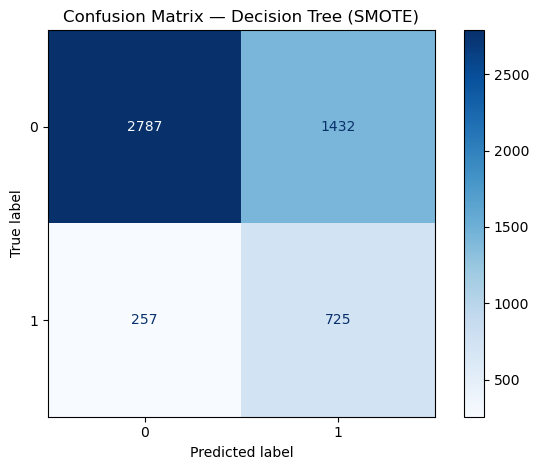

Accuracy: 0.6753
ROC AUC:  0.7560

Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.66      0.77      4219
         1.0       0.34      0.74      0.46       982

    accuracy                           0.68      5201
   macro avg       0.63      0.70      0.61      5201
weighted avg       0.81      0.68      0.71      5201



In [6]:
predictions        = best_model.predict(X_test_final)
pred_probabilities = best_model.predict_proba(X_test_final)[:, 1]

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Decision Tree (SMOTE)")
plt.tight_layout()
plt.show()

accuracy = accuracy_score(y_test, predictions)
roc_auc  = roc_auc_score(y_test, pred_probabilities)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC:  {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))


## Exporting Model Performance Metrics

Evaluation metrics are exported to a CSV file in `results/performance/`. This allows the comparison notebook to load results from all models without retraining.

In [7]:
os.makedirs("../../results/performance", exist_ok=True)

metrics = {
    "Model":     "Decision Tree",
    "Strategy":  "SMOTE",
    "Accuracy":  accuracy_score(y_test, predictions),
    "Precision": precision_score(y_test, predictions),
    "Recall":    recall_score(y_test, predictions),
    "F1-score":  f1_score(y_test, predictions),
    "ROC AUC":   roc_auc_score(y_test, pred_probabilities),
}

pd.DataFrame([metrics]).to_csv(
    "../../results/performance/decision_tree_A_metrics.csv",
    index=False
)
print("[OK] Performance metrics saved.")


[OK] Performance metrics saved.


## Feature Importance — SHAP (TreeExplainer)

`shap.TreeExplainer` computes exact Shapley values for tree-based models. For each test observation, SHAP assigns a contribution value to every feature, indicating how much that feature pushed the prediction above or below the base rate. The mean absolute SHAP value across all test observations is used as the overall importance score.

SHAP values are computed on the raw Decision Tree model extracted from the pipeline, using the original `X_test_final` feature matrix. The full ranking across all features is exported so it can be compared against other methods in the comparison notebook.

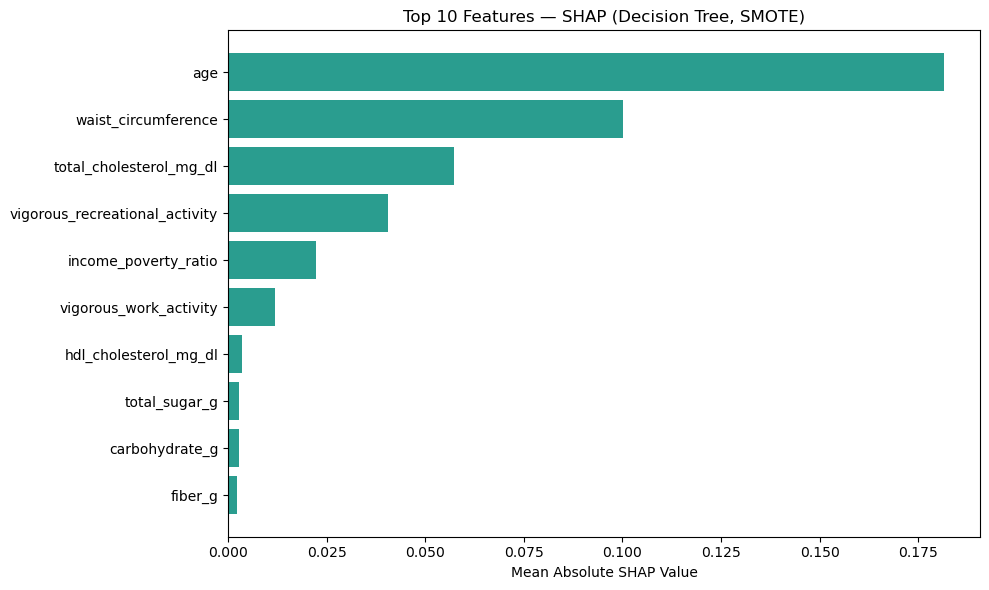

In [8]:
dt_model = best_model.named_steps["model"]

explainer   = shap.TreeExplainer(dt_model)
shap_output = explainer.shap_values(X_test_final)

if isinstance(shap_output, list):
    shap_values = shap_output[1]
elif len(shap_output.shape) == 3:
    shap_values = shap_output[:, :, 1]
else:
    shap_values = shap_output

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    "Feature":    X_test_final.columns,
    "Importance": mean_abs_shap
}).sort_values("Importance", ascending=False).reset_index(drop=True)

shap_df["Rank"]     = range(1, len(shap_df) + 1)
shap_df["Model"]    = "Decision Tree"
shap_df["Strategy"] = "SMOTE"
shap_df["Method"]   = "SHAP"

# Plot top 10
top10 = shap_df.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top10["Feature"][::-1], top10["Importance"][::-1], color="#2a9d8f")
plt.xlabel("Mean Absolute SHAP Value")
plt.title("Top 10 Features — SHAP (Decision Tree, SMOTE)")
plt.tight_layout()
plt.show()


## Feature Importance — Permutation Importance

Permutation importance measures how much the model's ROC AUC drops when the values of a single feature are randomly shuffled. A large drop indicates that the model relies heavily on that feature; a small or negative drop suggests the feature contributes little.

Permutation importance is computed on the full pipeline using the held-out test set. `n_repeats=20` shuffles each feature 20 times to reduce variance in the estimate. The full ranking across all features is exported for comparison.

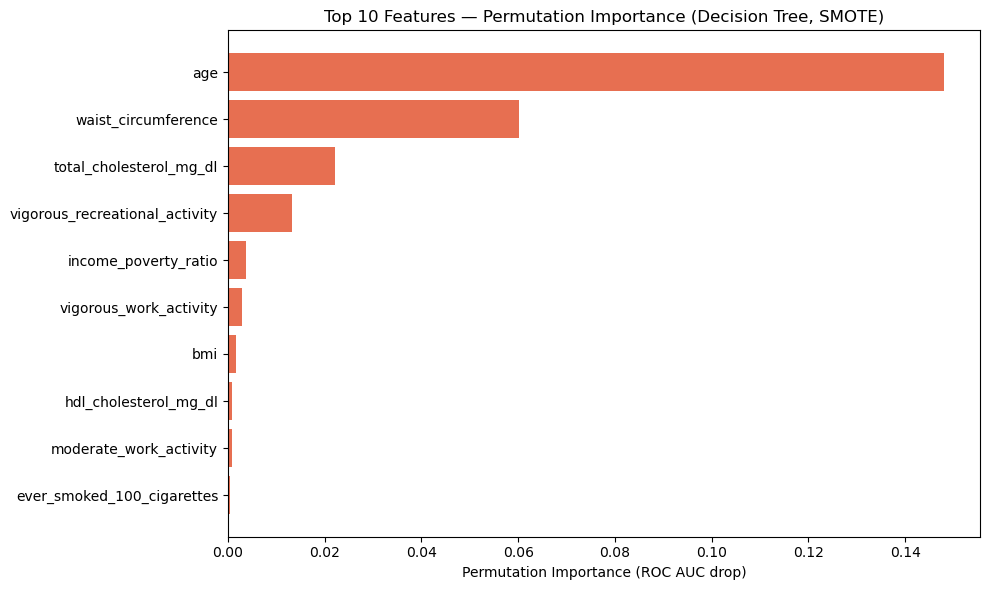

In [9]:
perm_result = permutation_importance(
    best_model,
    X_test_final,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature":        X_test_final.columns,
    "Importance":     perm_result.importances_mean,
    "Importance Std": perm_result.importances_std
}).sort_values("Importance", ascending=False).reset_index(drop=True)

perm_df["Rank"]     = range(1, len(perm_df) + 1)
perm_df["Model"]    = "Decision Tree"
perm_df["Strategy"] = "SMOTE"
perm_df["Method"]   = "Permutation"

# Plot top 10
top10 = perm_df.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top10["Feature"][::-1], top10["Importance"][::-1], color="#e76f51")
plt.xlabel("Permutation Importance (ROC AUC drop)")
plt.title("Top 10 Features — Permutation Importance (Decision Tree, SMOTE)")
plt.tight_layout()
plt.show()


## Feature Importance — Built-in Gini Importance

Decision Trees provide a model-specific importance score based on the total reduction in Gini impurity attributable to each feature across all splits in the tree. Features used higher in the tree (closer to the root) and more frequently tend to receive higher scores.

Note that Gini importance can be biased towards high-cardinality features and may differ from SHAP and permutation importance in ranking. This is one of the reasons why comparing multiple XAI methods is valuable for RQ4.

The full ranking across all features is exported for comparison.

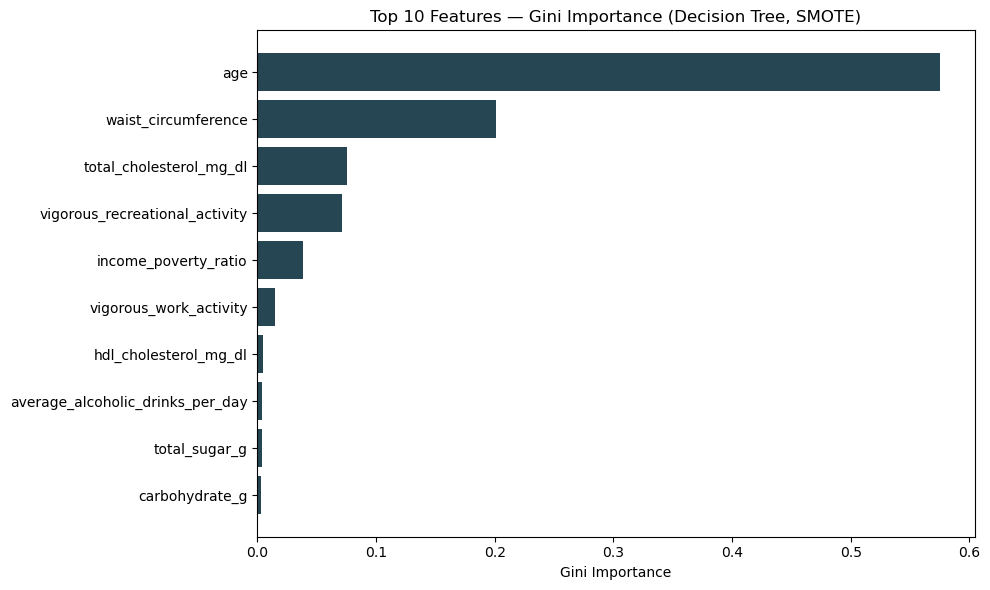

In [10]:
dt_model = best_model.named_steps["model"]

builtin_df = pd.DataFrame({
    "Feature":    X_test_final.columns,
    "Importance": dt_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

builtin_df["Rank"]     = range(1, len(builtin_df) + 1)
builtin_df["Model"]    = "Decision Tree"
builtin_df["Strategy"] = "SMOTE"
builtin_df["Method"]   = "Gini Importance"

# Plot top 10
top10 = builtin_df.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top10["Feature"][::-1], top10["Importance"][::-1], color="#264653")
plt.xlabel("Gini Importance")
plt.title("Top 10 Features — Gini Importance (Decision Tree, SMOTE)")
plt.tight_layout()
plt.show()


## Exporting Feature Importance Rankings

All three importance rankings are combined into a single CSV file in `results/features/`. Each row represents one feature under one method, with its importance score and rank. The full ranking (not just top 10) is saved so that Spearman rank correlations can be computed across all features in the comparison notebook.

In [11]:
os.makedirs("../../results/features", exist_ok=True)

cols = ["Model", "Strategy", "Method", "Rank", "Feature", "Importance"]

feature_importance_all = pd.concat([
    shap_df[cols],
    perm_df[cols],
    builtin_df[cols]
], ignore_index=True)

feature_importance_all.to_csv(
    "../../results/features/decision_tree_A_feature_importance.csv",
    index=False
)
print("[OK] Feature importance rankings saved.")
display(feature_importance_all.head(15))


[OK] Feature importance rankings saved.


,Model,Strategy,Method,Rank,Feature,Importance
0,Decision Tree,SMOTE,SHAP,1,age,0.181548
1,Decision Tree,SMOTE,SHAP,2,waist_circumference,0.100067
2,Decision Tree,SMOTE,SHAP,3,total_cholesterol_mg_dl,0.057393
3,Decision Tree,SMOTE,SHAP,4,vigorous_recreational_activity,0.040524
4,Decision Tree,SMOTE,SHAP,5,income_poverty_ratio,0.022362
5,Decision Tree,SMOTE,SHAP,6,vigorous_work_activity,0.012013
6,Decision Tree,SMOTE,SHAP,7,hdl_cholesterol_mg_dl,0.003605
7,Decision Tree,SMOTE,SHAP,8,total_sugar_g,0.002746
8,Decision Tree,SMOTE,SHAP,9,carbohydrate_g,0.002712
9,Decision Tree,SMOTE,SHAP,10,fiber_g,0.002350
